# 🧠 Notebook 1.5 — Estimativa empírica da janela pré-ictal

**Posição no pipeline:** NB1 → **NB1.5** → NB1 (re-roda) → NB2 → NB3

---
## Motivação

Definir o período pré-ictal como "X minutos antes do onset" de forma arbitrária
invalida qualquer avaliação do modelo — o rótulo define o que o modelo aprende,
e se o rótulo for escolhido sem justificativa, o resultado não é generalizável.

## Método

Para cada crise dos pacientes de calibração:
1. Extrai features espectrais/temporais em janelas de 30 s nos 60 min antes do onset
2. **PELT** (Pruned Exact Linear Time) detecta onde a dinâmica muda
3. **K-Means (K=2)** valida a separação via Silhouette Score
4. A distância (changepoint → onset) = duração estimada do pré-ictal dessa crise

A estimativa final é a **mediana** de todas as crises válidas — robusta a outliers.

## Tratamento de arquivos sem crise

Arquivos L1 sem crise (onsets vazio) são automaticamente pulados.
Crises com menos de 3 min de lookback disponível são descartadas.
Estimativas fora do intervalo [3 min, 50 min] são descartadas.

## Como decidir o valor final metodologicamente

A decisão é feita em 3 etapas neste notebook:
1. Análise progressiva (1 → 3 → 6 pacientes por dataset) — verifica estabilidade
2. Triagem por qualidade (Silhouette ≥ 0.5) — usa só estimativas confiáveis
3. Teste de sensibilidade — avalia quanto o resultado muda se você usar média vs mediana,
   ou se excluir outliers. Se a decisão for robusta a essas variações, ela é válida.


## 1. Imports e configuração

In [1]:
# Fix para bug joblib/wmic no Windows Python 3.13
# Deve vir ANTES de qualquer import de sklearn/ruptures
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

%pip install -q numpy pandas matplotlib scipy scikit-learn ruptures pywavelets

import re, json, glob, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import welch
from scipy.stats import kruskal, mannwhitneyu
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import ruptures as rpt
import pywt
import IPython.display as ipd

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Diretórios ────────────────────────────────────────────────────────────────
ROOT_DIR = 'data'
L1_DIR   = os.path.join(ROOT_DIR, 'level1_signals')
VIZ_DIR  = os.path.join(ROOT_DIR, 'nb15_viz')
OUT_JSON = os.path.join(ROOT_DIR, 'preictal_estimate.json')
os.makedirs(VIZ_DIR, exist_ok=True)

# ── Labels ────────────────────────────────────────────────────────────────────
LBL = dict(interictal=0, preictal=1, ictal=2, postictal=3, unknown=-1)

# ── Pacientes de calibração (6 por dataset) ───────────────────────────────────
# IMPORTANTE: estes pacientes NÃO devem entrar no conjunto de teste do NB3.
CALIB_PATIENTS = {
    'CHBMIT'  : ['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06'],
    'Siena'   : ['PN00', 'PN01', 'PN03', 'PN05', 'PN06', 'PN07'],
    'Mendeley': ['p10', 'p11', 'p12', 'p13', 'p14', 'p15'],
    'SeizeIT2': ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006'],
}

# ── Parâmetros do estimador ───────────────────────────────────────────────────
LOOKBACK_SEC     = 60 * 60   # máx. 60 min antes do onset
FEAT_WIN_SEC     = 30        # janela de feature
FEAT_STEP_SEC    = 30        # passo (sem overlap → menos memória)
PELT_PENALTY     = 3.0       # penalização PELT
PELT_MIN_SIZE    = 3         # mínimo 3 janelas entre CPs (= 1.5 min)
MIN_PREICTAL_SEC = 3  * 60   # descarta < 3 min
MAX_PREICTAL_SEC = 50 * 60   # descarta > 50 min
SIL_THRESHOLD    = 0.50      # silhouette mínimo para estimativa "confiável"

FEAT_NAMES = [
    'std', 'var', 'rms', 'line_len', 'activity', 'mobility',
    'delta', 'theta', 'alpha', 'beta', 'gamma', 'sp_entropy',
    'dwt_d1', 'dwt_d2', 'dwt_d3', 'dwt_d4',
]
TEMPORAL_HINTS = ['t3','t4','t5','t6','t7','t8','p7','p8',
                  'ft9','ft10','tp7','tp8','f7','f8']
DS_COLORS = {'CHBMIT':'#4C72B0','Siena':'#DD8452',
             'Mendeley':'#55A868','SeizeIT2':'#C44E52'}

print('✅ Config OK')
l1_all = sorted(glob.glob(os.path.join(L1_DIR, '*_L1.npz')))
print(f'   L1 no disco: {len(l1_all)}')
for ds, pats in CALIB_PATIENTS.items():
    n_match = sum(1 for f in l1_all
                  if any(f'__{p}__' in os.path.basename(f) for p in pats))
    print(f'   {ds:9}: {len(pats)} pacientes configurados | {n_match} L1 encontrados')



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ Config OK
   L1 no disco: 85
   CHBMIT   : 6 pacientes configurados | 29 L1 encontrados
   Siena    : 6 pacientes configurados | 17 L1 encontrados
   Mendeley : 6 pacientes configurados | 20 L1 encontrados
   SeizeIT2 : 6 pacientes configurados | 16 L1 encontrados


## 2. Funções de feature e estimador

In [2]:
_BANDS = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,40)}

def channel_feats(sig, sfreq):
    d1  = np.diff(sig); act = float(np.var(sig))
    mob = float(np.sqrt(np.var(d1) / (act + 1e-10)))
    temporal = [float(np.std(sig)), act, float(np.sqrt(np.mean(sig**2))),
                float(np.sum(np.abs(d1))), act, mob]
    nperseg = min(int(sfreq*4), max(int(sfreq), len(sig)//2))
    f, psd  = welch(sig, fs=sfreq, nperseg=nperseg)
    bp = []
    for lo, hi in _BANDS.values():
        idx = (f >= lo) & (f <= hi)
        bp.append(float(np.trapz(psd[idx], f[idx])) if idx.sum() > 1 else 0.0)
    pn = psd / (psd.sum() + 1e-10); pn = pn[pn > 0]
    spectral = bp + [float(-np.sum(pn * np.log(pn)))]
    c   = pywt.wavedec(sig.astype(np.float64), 'db4', level=4)
    dwt = [float(np.sum(x**2)) for x in c[1:5]]
    return np.array(temporal + spectral + dwt, dtype=np.float32)

def temporal_ch_idx(ch_names):
    idx = [i for i, c in enumerate(ch_names)
           if any(h in str(c).lower() for h in TEMPORAL_HINTS)]
    return idx if idx else list(range(len(ch_names)))

def extract_preonset_features(data, sfreq, onset_sample, prev_offset=0):
    """Extrai features em janelas de 30s antes do onset. Pula arquivo se sem crise."""
    ws   = int(FEAT_WIN_SEC  * sfreq)
    step = int(FEAT_STEP_SEC * sfreq)
    look = int(LOOKBACK_SEC  * sfreq)
    ch_idx    = temporal_ch_idx(list(range(data.shape[0])))
    win_start = max(0, onset_sample - look, prev_offset)
    feats, starts = [], []
    for s in range(win_start, onset_sample - ws + 1, step):
        seg  = data[ch_idx, s:s+ws]
        fvec = np.mean([channel_feats(seg[c], sfreq)
                        for c in range(seg.shape[0])], axis=0)
        feats.append(fvec)
        starts.append((s - onset_sample) / sfreq / 60)   # minutos, negativo
    if not feats:
        return np.empty((0, 16), dtype=np.float32), np.empty(0)
    return np.array(feats, dtype=np.float32), np.array(starts)

def estimate_preictal_window(feats, starts_min):
    """PELT + K-Means. Retorna (dur_min, cp_min, n_cp, silhouette, Xn_normalizado)."""
    if len(feats) < 2 * PELT_MIN_SIZE:
        return None, None, 0, None, None
    Xn = StandardScaler().fit_transform(feats)
    try:
        algo = rpt.Pelt(model='rbf', min_size=PELT_MIN_SIZE).fit(Xn)
        cps  = [c for c in algo.predict(pen=PELT_PENALTY) if c < len(feats)]
    except Exception:
        return None, None, 0, None, Xn
    if not cps:
        return None, None, 0, None, Xn
    cp_idx  = max(cps)
    dur_min = abs(float(starts_min[cp_idx]))
    sil = None
    if len(feats) >= 4:
        try:
            km  = KMeans(n_clusters=2, n_init=10, random_state=42).fit(Xn)
            sil = float(silhouette_score(Xn, km.labels_))
        except Exception:
            pass
    if dur_min < MIN_PREICTAL_SEC/60 or dur_min > MAX_PREICTAL_SEC/60:
        return None, float(starts_min[cp_idx]), len(cps), sil, Xn
    return dur_min, float(starts_min[cp_idx]), len(cps), sil, Xn

print('✅ Funções definidas')


✅ Funções definidas


## 3. Função de calibração

In [3]:
def run_calib(patients_subset, label='', viz_max=2, verbose=True):
    """
    Processa os L1 dos pacientes em patients_subset.
    Arquivos sem crise (onsets vazio) são pulados automaticamente.
    Retorna (df_results, df_skipped, viz_cache).
    """
    calib_set = {(ds, p)
                 for ds, pats in patients_subset.items() for p in pats}
    results, skipped, viz_cache = [], [], []
    l1_files = sorted(glob.glob(os.path.join(L1_DIR, '*_L1.npz')))

    for npz_path in l1_files:
        base = os.path.basename(npz_path)
        m = re.match(r'(.+?)__(.+?)__(.+)_L1\.npz', base)
        if not m: continue
        ds, pat, fkey = m.group(1), m.group(2), m.group(3)
        if (ds, pat) not in calib_set: continue

        try:
            npz    = np.load(npz_path, allow_pickle=True)
            data   = npz['data']
            labels = npz['labels']
            sfreq  = float(npz['sfreq'])
        except Exception as e:
            print(f'  ⚠️  {base}: {e}'); continue

        # Detecta onsets ictais a partir das labels
        is_ic   = (labels == LBL['ictal']).astype(np.int8)
        edges   = np.diff(is_ic)
        onsets  = np.where(edges ==  1)[0] + 1
        offsets = np.where(edges == -1)[0] + 1
        if is_ic[0]  == 1: onsets  = np.r_[0,       onsets]
        if is_ic[-1] == 1: offsets = np.r_[offsets,  len(labels)]

        # Arquivo sem crise → pula (tratamento explícito)
        if len(onsets) == 0:
            if verbose: print(f'  ⏭️  {base}: sem crise — pulado')
            del npz, data, labels; gc.collect(); continue

        for k, onset in enumerate(onsets):
            prev_off = offsets[k-1] if k > 0 else 0
            avail_min = (onset - prev_off) / sfreq / 60
            feats, starts_min = extract_preonset_features(data, sfreq, onset, prev_off)
            dur_min, cp_min, n_cp, sil, Xn = estimate_preictal_window(feats, starts_min)

            row = dict(dataset=ds, patient=pat, file=fkey, seizure_idx=k,
                       onset_sec=round(onset/sfreq, 1),
                       lookback_avail_min=round(avail_min, 1),
                       n_feat_windows=len(feats), n_changepoints=n_cp,
                       silhouette=round(sil, 3) if sil is not None else None,
                       reliable=sil is not None and sil >= SIL_THRESHOLD,
                       preictal_est_min=round(dur_min, 2) if dur_min is not None else None)

            if dur_min is not None:
                results.append(row)
                if len(viz_cache) < viz_max and Xn is not None:
                    algo2 = rpt.Pelt(model='rbf', min_size=PELT_MIN_SIZE).fit(Xn)
                    cps2  = [c for c in algo2.predict(pen=PELT_PENALTY) if c < len(feats)]
                    viz_cache.append(dict(
                        feats=feats.copy(), starts_min=starts_min.copy(),
                        Xn=Xn.copy(), cps=cps2,
                        cp_best=max(cps2) if cps2 else None,
                        ds=ds, pat=pat, sz_idx=k,
                        dur_min=dur_min, sil=sil))
            else:
                skipped.append(row)

        del npz, data, labels, feats, starts_min
        gc.collect()

    df_r = pd.DataFrame(results)
    df_s = pd.DataFrame(skipped)
    if not df_r.empty and verbose:
        rel = df_r['reliable'].sum()
        print(f'  ✅ {label}: {len(df_r)} estimativas válidas | '
              f'{len(df_s)} descartadas | {rel} confiáveis (sil≥{SIL_THRESHOLD})')
        med_all = df_r['preictal_est_min'].median()
        med_rel = df_r[df_r['reliable']]['preictal_est_min'].median()
        print(f'     Mediana (todas):      {med_all:.1f} min')
        print(f'     Mediana (confiáveis): {med_rel:.1f} min'
              if not np.isnan(med_rel) else '     Sem estimativas confiáveis')
    elif verbose:
        print(f'  ⚠️  {label}: nenhuma estimativa válida')
    return df_r, df_s, viz_cache

print('✅ run_calib definida')


✅ run_calib definida


## 4. Análise progressiva por dataset (1 → 3 → 6 pacientes)

Objetivo: verificar a **estabilidade** da estimativa conforme mais pacientes são adicionados.
Se a mediana variar pouco entre 3 e 6 pacientes, ela é robusta e pode ser adotada com confiança.


### CHBMIT

In [4]:
_sub = {'CHBMIT': CALIB_PATIENTS['CHBMIT'][:1]}
print(f'Pacientes: {_sub["CHBMIT"]}')
df_chbmit_1, _, viz_chbmit_1 = run_calib(
    _sub, label='CHBMIT — 1 pac.', viz_max=2)
if not df_chbmit_1.empty:
    ipd.display(df_chbmit_1.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['chb01']
  ✅ CHBMIT — 1 pac.: 6 estimativas válidas | 1 descartadas | 2 confiáveis (sil≥0.5)
     Mediana (todas):      14.2 min
     Mediana (confiáveis): 19.2 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,CHBMIT,chb01,chb01_03,0,2996,49.9,99,2,0.510,True,19.93
1,CHBMIT,chb01,chb01_04,0,1467,24.4,48,1,0.443,False,11.95
2,CHBMIT,chb01,chb01_15,0,1732,28.9,57,1,0.307,False,16.37
3,CHBMIT,chb01,chb01_16,0,1015,16.9,33,1,0.377,False,11.92
4,CHBMIT,chb01,chb01_18,0,1720,28.7,57,1,0.433,False,6.17
5,CHBMIT,chb01,chb01_26,0,1862,31.0,62,1,0.537,True,18.53


In [5]:
_sub = {'CHBMIT': CALIB_PATIENTS['CHBMIT'][:3]}
print(f'Pacientes: {_sub["CHBMIT"]}')
df_chbmit_3, _, viz_chbmit_3 = run_calib(
    _sub, label='CHBMIT — 3 pac.', viz_max=2)
if not df_chbmit_3.empty:
    ipd.display(df_chbmit_3.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['chb01', 'chb02', 'chb03']
  ✅ CHBMIT — 3 pac.: 9 estimativas válidas | 5 descartadas | 4 confiáveis (sil≥0.5)
     Mediana (todas):      11.9 min
     Mediana (confiáveis): 13.4 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,CHBMIT,chb01,chb01_03,0,2996,49.9,99,2,0.510,True,19.93
1,CHBMIT,chb01,chb01_04,0,1467,24.4,48,1,0.443,False,11.95
2,CHBMIT,chb01,chb01_15,0,1732,28.9,57,1,0.307,False,16.37
3,CHBMIT,chb01,chb01_16,0,1015,16.9,33,1,0.377,False,11.92
4,CHBMIT,chb01,chb01_18,0,1720,28.7,57,1,0.433,False,6.17
5,CHBMIT,chb01,chb01_26,0,1862,31.0,62,1,0.537,True,18.53
6,CHBMIT,chb03,chb03_04,0,2162,36.0,72,2,0.480,False,3.53
7,CHBMIT,chb03,chb03_34,0,1982,33.0,66,1,0.772,True,8.03
8,CHBMIT,chb03,chb03_35,0,2592,43.2,86,2,0.677,True,8.20


In [6]:
_sub = {'CHBMIT': CALIB_PATIENTS['CHBMIT'][:6]}
print(f'Pacientes: {_sub["CHBMIT"]}')
df_chbmit_6, _, viz_chbmit_6 = run_calib(
    _sub, label='CHBMIT — 6 pac.', viz_max=2)
if not df_chbmit_6.empty:
    ipd.display(df_chbmit_6.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06']
  ✅ CHBMIT — 6 pac.: 21 estimativas válidas | 12 descartadas | 10 confiáveis (sil≥0.5)
     Mediana (todas):      11.9 min
     Mediana (confiáveis): 10.4 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,CHBMIT,chb01,chb01_03,0,2996,49.9,99,2,0.510,True,19.93
1,CHBMIT,chb01,chb01_04,0,1467,24.4,48,1,0.443,False,11.95
2,CHBMIT,chb01,chb01_15,0,1732,28.9,57,1,0.307,False,16.37
3,CHBMIT,chb01,chb01_16,0,1015,16.9,33,1,0.377,False,11.92
4,CHBMIT,chb01,chb01_18,0,1720,28.7,57,1,0.433,False,6.17
5,CHBMIT,chb01,chb01_26,0,1862,31.0,62,1,0.537,True,18.53
6,CHBMIT,chb03,chb03_04,0,2162,36.0,72,2,0.480,False,3.53
7,CHBMIT,chb03,chb03_34,0,1982,33.0,66,1,0.772,True,8.03
8,CHBMIT,chb03,chb03_35,0,2592,43.2,86,2,0.677,True,8.20
9,CHBMIT,chb04,chb04_05,0,7804,130.1,120,1,0.889,True,7.50


### Siena

In [7]:
_sub = {'Siena': CALIB_PATIENTS['Siena'][:1]}
print(f'Pacientes: {_sub["Siena"]}')
df_siena_1, _, viz_siena_1 = run_calib(
    _sub, label='Siena — 1 pac.', viz_max=2)
if not df_siena_1.empty:
    ipd.display(df_siena_1.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['PN00']
  ✅ Siena — 1 pac.: 2 estimativas válidas | 3 descartadas | 2 confiáveis (sil≥0.5)
     Mediana (todas):      15.2 min
     Mediana (confiáveis): 15.2 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,Siena,PN00,PN00-2,0,1220,20.3,40,1,0.816,True,17.83
1,Siena,PN00,PN00-5,0,904,15.1,30,1,0.667,True,12.57


In [8]:
_sub = {'Siena': CALIB_PATIENTS['Siena'][:3]}
print(f'Pacientes: {_sub["Siena"]}')
df_siena_3, _, viz_siena_3 = run_calib(
    _sub, label='Siena — 3 pac.', viz_max=2)
if not df_siena_3.empty:
    ipd.display(df_siena_3.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['PN00', 'PN01', 'PN03']
  ⏭️  Siena__PN03__PN03-1_L1.npz: sem crise — pulado
  ✅ Siena — 3 pac.: 5 estimativas válidas | 3 descartadas | 4 confiáveis (sil≥0.5)
     Mediana (todas):      17.8 min
     Mediana (confiáveis): 16.4 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,Siena,PN00,PN00-2,0,1220,20.3,40,1,0.816,True,17.83
1,Siena,PN00,PN00-5,0,904,15.1,30,1,0.667,True,12.57
2,Siena,PN01,PN01-1,0,10218,170.3,120,1,0.453,False,30.00
3,Siena,PN01,PN01-1,1,46353,601.4,120,3,0.681,True,15.00
4,Siena,PN03,PN03-2,0,34921,582.0,120,1,0.880,True,22.50


In [9]:
_sub = {'Siena': CALIB_PATIENTS['Siena'][:6]}
print(f'Pacientes: {_sub["Siena"]}')
df_siena_6, _, viz_siena_6 = run_calib(
    _sub, label='Siena — 6 pac.', viz_max=2)
if not df_siena_6.empty:
    ipd.display(df_siena_6.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['PN00', 'PN01', 'PN03', 'PN05', 'PN06', 'PN07']
  ⏭️  Siena__PN03__PN03-1_L1.npz: sem crise — pulado
  ⏭️  Siena__PN06__PN06-5_L1.npz: sem crise — pulado
  ⏭️  Siena__PN07__PN07-1_L1.npz: sem crise — pulado
  ✅ Siena — 6 pac.: 11 estimativas válidas | 4 descartadas | 10 confiáveis (sil≥0.5)
     Mediana (todas):      15.0 min
     Mediana (confiáveis): 13.8 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,Siena,PN00,PN00-2,0,1220,20.3,40,1,0.816,True,17.83
1,Siena,PN00,PN00-5,0,904,15.1,30,1,0.667,True,12.57
2,Siena,PN01,PN01-1,0,10218,170.3,120,1,0.453,False,30.00
3,Siena,PN01,PN01-1,1,46353,601.4,120,3,0.681,True,15.00
4,Siena,PN03,PN03-2,0,34921,582.0,120,1,0.880,True,22.50
5,Siena,PN05,PN05-2,0,7163,119.4,120,2,0.600,True,12.50
6,Siena,PN05,PN05-3,0,6836,113.9,120,2,0.586,True,25.00
7,Siena,PN05,PN05-4,0,3608,60.1,120,2,0.657,True,7.50
8,Siena,PN06,PN06-1,0,5583,93.0,120,3,0.880,True,15.00
9,Siena,PN06,PN06-2,0,8860,147.7,120,4,0.611,True,5.00


### Mendeley

In [10]:
_sub = {'Mendeley': CALIB_PATIENTS['Mendeley'][:1]}
print(f'Pacientes: {_sub["Mendeley"]}')
df_mendeley_1, _, viz_mendeley_1 = run_calib(
    _sub, label='Mendeley — 1 pac.', viz_max=2)
if not df_mendeley_1.empty:
    ipd.display(df_mendeley_1.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['p10']
  ✅ Mendeley — 1 pac.: 2 estimativas válidas | 0 descartadas | 2 confiáveis (sil≥0.5)
     Mediana (todas):      8.8 min
     Mediana (confiáveis): 8.8 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,Mendeley,p10,p10_Record1,0,7199,120.0,120,3,0.797,True,5.00
1,Mendeley,p10,p10_Record2,0,7200,120.0,120,2,0.629,True,12.50


In [11]:
_sub = {'Mendeley': CALIB_PATIENTS['Mendeley'][:3]}
print(f'Pacientes: {_sub["Mendeley"]}')
df_mendeley_3, _, viz_mendeley_3 = run_calib(
    _sub, label='Mendeley — 3 pac.', viz_max=2)
if not df_mendeley_3.empty:
    ipd.display(df_mendeley_3.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['p10', 'p11', 'p12']
  ✅ Mendeley — 3 pac.: 13 estimativas válidas | 3 descartadas | 11 confiáveis (sil≥0.5)
     Mediana (todas):      15.0 min
     Mediana (confiáveis): 15.0 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,Mendeley,p10,p10_Record1,0,7199,120.0,120,3,0.797,True,5.00
1,Mendeley,p10,p10_Record2,0,7200,120.0,120,2,0.629,True,12.50
2,Mendeley,p11,p11_Record1,0,4205,70.1,120,2,0.281,False,10.00
3,Mendeley,p11,p11_Record2,0,6372,106.2,120,2,0.872,True,15.00
4,Mendeley,p11,p11_Record3,1,4397,46.5,92,2,0.828,True,11.48
5,Mendeley,p11,p11_Record3,2,7201,45.4,90,1,0.836,True,35.35
6,Mendeley,p11,p11_Record3,3,9243,32.8,65,1,0.430,False,22.77
7,Mendeley,p11,p11_Record4,0,7177,119.6,120,2,0.709,True,15.00
8,Mendeley,p12,p12_Record1,1,7194,22.7,45,1,0.782,True,15.20
9,Mendeley,p12,p12_Record2,0,7202,120.0,120,1,0.632,True,32.50


In [12]:
_sub = {'Mendeley': CALIB_PATIENTS['Mendeley'][:6]}
print(f'Pacientes: {_sub["Mendeley"]}')
df_mendeley_6, _, viz_mendeley_6 = run_calib(
    _sub, label='Mendeley — 6 pac.', viz_max=2)
if not df_mendeley_6.empty:
    ipd.display(df_mendeley_6.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['p10', 'p11', 'p12', 'p13', 'p14', 'p15']
  ✅ Mendeley — 6 pac.: 29 estimativas válidas | 5 descartadas | 22 confiáveis (sil≥0.5)
     Mediana (todas):      15.0 min
     Mediana (confiáveis): 14.5 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,Mendeley,p10,p10_Record1,0,7199,120.0,120,3,0.797,True,5.00
1,Mendeley,p10,p10_Record2,0,7200,120.0,120,2,0.629,True,12.50
2,Mendeley,p11,p11_Record1,0,4205,70.1,120,2,0.281,False,10.00
3,Mendeley,p11,p11_Record2,0,6372,106.2,120,2,0.872,True,15.00
4,Mendeley,p11,p11_Record3,1,4397,46.5,92,2,0.828,True,11.48
5,Mendeley,p11,p11_Record3,2,7201,45.4,90,1,0.836,True,35.35
6,Mendeley,p11,p11_Record3,3,9243,32.8,65,1,0.430,False,22.77
7,Mendeley,p11,p11_Record4,0,7177,119.6,120,2,0.709,True,15.00
8,Mendeley,p12,p12_Record1,1,7194,22.7,45,1,0.782,True,15.20
9,Mendeley,p12,p12_Record2,0,7202,120.0,120,1,0.632,True,32.50


### SeizeIT2

In [13]:
_sub = {'SeizeIT2': CALIB_PATIENTS['SeizeIT2'][:1]}
print(f'Pacientes: {_sub["SeizeIT2"]}')
df_seizeit2_1, _, viz_seizeit2_1 = run_calib(
    _sub, label='SeizeIT2 — 1 pac.', viz_max=2)
if not df_seizeit2_1.empty:
    ipd.display(df_seizeit2_1.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['sub-001']
  ✅ SeizeIT2 — 1 pac.: 4 estimativas válidas | 0 descartadas | 4 confiáveis (sil≥0.5)
     Mediana (todas):      13.8 min
     Mediana (confiáveis): 13.8 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-03_eeg,0,57975,966.2,120,3,0.940,True,15.00
1,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-05_eeg,0,60968,1016.1,120,3,0.864,True,12.50
2,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-07_eeg,0,16300,271.7,120,3,0.879,True,25.00
3,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-08_eeg,0,28285,471.4,120,2,0.907,True,12.50


In [14]:
_sub = {'SeizeIT2': CALIB_PATIENTS['SeizeIT2'][:3]}
print(f'Pacientes: {_sub["SeizeIT2"]}')
df_seizeit2_3, _, viz_seizeit2_3 = run_calib(
    _sub, label='SeizeIT2 — 3 pac.', viz_max=2)
if not df_seizeit2_3.empty:
    ipd.display(df_seizeit2_3.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['sub-001', 'sub-002', 'sub-003']
  ✅ SeizeIT2 — 3 pac.: 18 estimativas válidas | 2 descartadas | 18 confiáveis (sil≥0.5)
     Mediana (todas):      15.0 min
     Mediana (confiáveis): 15.0 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-03_eeg,0,57975,966.2,120,3,0.940,True,15.00
1,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-05_eeg,0,60968,1016.1,120,3,0.864,True,12.50
2,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-07_eeg,0,16300,271.7,120,3,0.879,True,25.00
3,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-08_eeg,0,28285,471.4,120,2,0.907,True,12.50
4,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-01_eeg,0,4046,67.4,120,2,0.575,True,5.00
5,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-01_eeg,1,10629,109.4,120,2,0.553,True,22.50
6,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-02_eeg,0,5224,87.1,120,2,0.532,True,7.50
7,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-02_eeg,1,13745,140.2,120,1,0.910,True,37.50
8,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-05_eeg,0,69796,1163.3,120,1,0.920,True,15.00
9,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-05_eeg,1,74529,76.3,120,3,0.917,True,10.00


In [15]:
_sub = {'SeizeIT2': CALIB_PATIENTS['SeizeIT2'][:6]}
print(f'Pacientes: {_sub["SeizeIT2"]}')
df_seizeit2_6, _, viz_seizeit2_6 = run_calib(
    _sub, label='SeizeIT2 — 6 pac.', viz_max=2)
if not df_seizeit2_6.empty:
    ipd.display(df_seizeit2_6.style.format({
        'preictal_est_min': '{:.2f}',
        'silhouette': '{:.3f}',
        'onset_sec': '{:.0f}',
        'lookback_avail_min': '{:.1f}',
    }).background_gradient(subset=['silhouette'], cmap='RdYlGn', vmin=0, vmax=1)
       .background_gradient(subset=['preictal_est_min'], cmap='Blues'))
print()


Pacientes: ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006']
  ✅ SeizeIT2 — 6 pac.: 25 estimativas válidas | 2 descartadas | 24 confiáveis (sil≥0.5)
     Mediana (todas):      17.6 min
     Mediana (confiáveis): 16.3 min


,dataset,patient,file,seizure_idx,onset_sec,lookback_avail_min,n_feat_windows,n_changepoints,silhouette,reliable,preictal_est_min
0,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-03_eeg,0,57975,966.2,120,3,0.940,True,15.00
1,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-05_eeg,0,60968,1016.1,120,3,0.864,True,12.50
2,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-07_eeg,0,16300,271.7,120,3,0.879,True,25.00
3,SeizeIT2,sub-001,sub-001_ses-01_task-szMonitoring_run-08_eeg,0,28285,471.4,120,2,0.907,True,12.50
4,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-01_eeg,0,4046,67.4,120,2,0.575,True,5.00
5,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-01_eeg,1,10629,109.4,120,2,0.553,True,22.50
6,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-02_eeg,0,5224,87.1,120,2,0.532,True,7.50
7,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-02_eeg,1,13745,140.2,120,1,0.910,True,37.50
8,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-05_eeg,0,69796,1163.3,120,1,0.920,True,15.00
9,SeizeIT2,sub-002,sub-002_ses-01_task-szMonitoring_run-05_eeg,1,74529,76.3,120,3,0.917,True,10.00


## 5. Convergência da estimativa por dataset

Mostra como a mediana evolui conforme pacientes são adicionados.
Se as linhas convergem, a estimativa é estável.


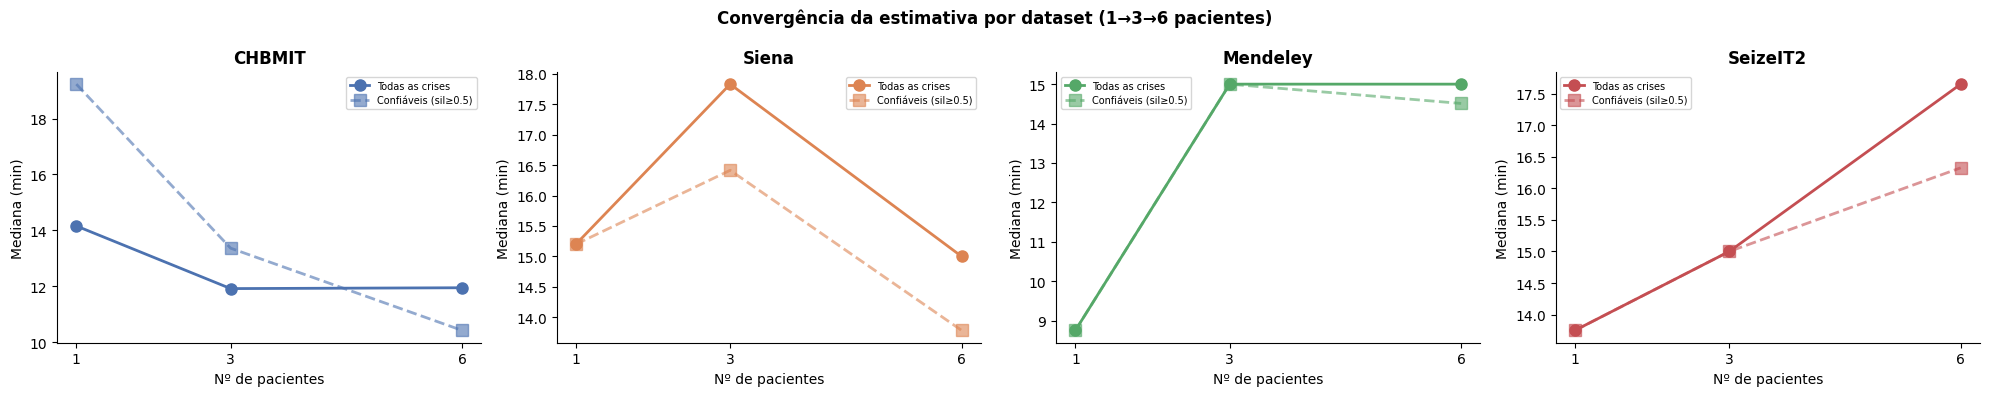

💾 data\nb15_viz\v0_convergence.png


In [16]:
DATASETS = ['CHBMIT', 'Siena', 'Mendeley', 'SeizeIT2']

fig, axes = plt.subplots(1, len(DATASETS), figsize=(5*len(DATASETS), 4))
fig.suptitle('Convergência da estimativa por dataset (1→3→6 pacientes)',
             fontsize=12, fontweight='bold')

for ax, ds in zip(axes, DATASETS):
    medians_all = []
    medians_rel = []
    ns = [1, 3, 6]
    for n in ns:
        df = locals().get(f'df_{ds.lower()}_{n}', pd.DataFrame())
        if df.empty:
            medians_all.append(np.nan); medians_rel.append(np.nan)
        else:
            medians_all.append(df['preictal_est_min'].median())
            rel = df[df['reliable']]['preictal_est_min']
            medians_rel.append(rel.median() if not rel.empty else np.nan)
    ax.plot(ns, medians_all, 'o-', color=DS_COLORS[ds], lw=2, ms=8,
            label='Todas as crises')
    ax.plot(ns, medians_rel, 's--', color=DS_COLORS[ds], lw=2, ms=8,
            alpha=0.6, label=f'Confiáveis (sil≥{SIL_THRESHOLD})')
    ax.set_title(ds, fontweight='bold')
    ax.set_xlabel('Nº de pacientes')
    ax.set_ylabel('Mediana (min)')
    ax.set_xticks(ns)
    ax.legend(fontsize=7)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
p = os.path.join(VIZ_DIR, 'v0_convergence.png')
plt.savefig(p, dpi=140, bbox_inches='tight'); plt.show()
print(f'💾 {p}')

## 6. Agregação final e estatísticas completas

Usa os resultados de **6 pacientes por dataset**.


In [17]:
# ── Junta todos os resultados de 6 pacientes ─────────────────────────────────
frames = []
for ds in DATASETS:
    df = locals().get(f'df_{ds.lower()}_6', pd.DataFrame())
    if not df.empty: frames.append(df)

if not frames:
    raise RuntimeError('Execute as células anteriores primeiro.')

df_res = pd.concat(frames, ignore_index=True)
df_rel = df_res[df_res['reliable']].copy()   # só estimativas confiáveis

print(f'Total de estimativas válidas:     {len(df_res)}')
print(f'Estimativas confiáveis (sil≥{SIL_THRESHOLD}): {len(df_rel)}')
print(f'Taxa de confiabilidade:           {len(df_rel)/len(df_res)*100:.1f}%')


Total de estimativas válidas:     86
Estimativas confiáveis (sil≥0.5): 66
Taxa de confiabilidade:           76.7%


In [18]:
# ── Estatísticas por PACIENTE ─────────────────────────────────────────────────
def pat_summary(df):
    rows = []
    for (ds, pat), g in df.groupby(['dataset','patient']):
        est = g['preictal_est_min'].values
        sil = g['silhouette'].dropna().values
        rows.append({
            'dataset'        : ds, 'patient': pat,
            'n_crises'       : len(est),
            'n_confiáveis'   : int((g['silhouette'] >= SIL_THRESHOLD).sum()),
            'mean_min'       : round(float(np.mean(est)),   2),
            'median_min'     : round(float(np.median(est)), 2),
            'std_min'        : round(float(np.std(est)),    2),
            'min_min'        : round(float(np.min(est)),    2),
            'max_min'        : round(float(np.max(est)),    2),
            'cv_pct'         : round(float(np.std(est)/np.mean(est)*100), 1)
                               if np.mean(est) > 0 else None,
            'mean_silhouette': round(float(np.mean(sil)), 3) if len(sil) > 0 else None,
        })
    return pd.DataFrame(rows)

print('ESTATÍSTICAS POR PACIENTE (todas as estimativas)')
print('='*70)
ipd.display(pat_summary(df_res))

print('\nESTATÍSTICAS POR PACIENTE (apenas confiáveis, sil≥{})'.format(SIL_THRESHOLD))
print('='*70)
if not df_rel.empty:
    ipd.display(pat_summary(df_rel))
else:
    print('Nenhuma estimativa confiável.')


ESTATÍSTICAS POR PACIENTE (todas as estimativas)


,dataset,patient,n_crises,n_confiáveis,mean_min,median_min,std_min,min_min,max_min,cv_pct,mean_silhouette
0,CHBMIT,chb01,6,2,14.15,14.16,4.67,6.17,19.93,33.0,0.434
1,CHBMIT,chb03,3,2,6.59,8.03,2.16,3.53,8.20,32.8,0.643
2,CHBMIT,chb04,3,2,13.62,7.50,11.71,3.35,30.00,86.0,0.629
3,CHBMIT,chb05,3,3,12.87,10.85,6.49,6.12,21.63,50.4,0.633
4,CHBMIT,chb06,6,1,18.75,17.50,7.47,10.00,30.00,39.8,0.397
5,Mendeley,p10,2,2,8.75,8.75,3.75,5.00,12.50,42.9,0.713
6,Mendeley,p11,6,4,18.27,15.00,8.64,10.00,35.35,47.3,0.659
7,Mendeley,p12,5,5,25.01,32.23,10.26,10.12,35.00,41.0,0.768
8,Mendeley,p13,6,5,15.53,12.01,9.79,6.67,35.00,63.0,0.674
9,Mendeley,p14,5,4,13.69,12.50,6.13,4.72,20.78,44.8,0.650



ESTATÍSTICAS POR PACIENTE (apenas confiáveis, sil≥0.5)


,dataset,patient,n_crises,n_confiáveis,mean_min,median_min,std_min,min_min,max_min,cv_pct,mean_silhouette
0,CHBMIT,chb01,2,2,19.23,19.23,0.70,18.53,19.93,3.6,0.524
1,CHBMIT,chb03,2,2,8.11,8.11,0.08,8.03,8.20,1.0,0.725
2,CHBMIT,chb04,2,2,18.75,18.75,11.25,7.50,30.00,60.0,0.700
3,CHBMIT,chb05,3,3,12.87,10.85,6.49,6.12,21.63,50.4,0.633
4,CHBMIT,chb06,1,1,10.00,10.00,0.00,10.00,10.00,0.0,0.633
5,Mendeley,p10,2,2,8.75,8.75,3.75,5.00,12.50,42.9,0.713
6,Mendeley,p11,4,4,19.21,15.00,9.43,11.48,35.35,49.1,0.811
7,Mendeley,p12,5,5,25.01,32.23,10.26,10.12,35.00,41.0,0.768
8,Mendeley,p13,5,5,16.64,14.02,10.37,6.67,35.00,62.4,0.721
9,Mendeley,p14,4,4,11.92,11.34,5.59,4.72,20.27,46.9,0.735


In [19]:
# ── Estatísticas por DATASET ──────────────────────────────────────────────────
def ds_summary(df, label=''):
    rows = []
    for ds, g in df.groupby('dataset'):
        est = g['preictal_est_min'].values
        sil = g['silhouette'].dropna().values
        rows.append({
            'dataset'        : ds,
            'n_crises'       : len(est),
            'n_pacientes'    : g['patient'].nunique(),
            'mean_min'       : round(float(np.mean(est)),           2),
            'median_min'     : round(float(np.median(est)),         2),
            'std_min'        : round(float(np.std(est)),            2),
            'q25_min'        : round(float(np.percentile(est, 25)), 2),
            'q75_min'        : round(float(np.percentile(est, 75)), 2),
            'min_min'        : round(float(np.min(est)),            2),
            'max_min'        : round(float(np.max(est)),            2),
            'cv_pct'         : round(float(np.std(est)/np.mean(est)*100), 1)
                               if np.mean(est) > 0 else None,
            'mean_silhouette': round(float(np.mean(sil)), 3) if len(sil) > 0 else None,
            'pct_confiáveis' : round(float((g['silhouette']>=SIL_THRESHOLD).sum()
                               /len(g)*100), 1),
        })
    return pd.DataFrame(rows)

print('ESTATÍSTICAS POR DATASET (todas as estimativas)')
print('='*70)
ipd.display(ds_summary(df_res))

print('\nESTATÍSTICAS POR DATASET (apenas confiáveis)')
print('='*70)
if not df_rel.empty:
    ipd.display(ds_summary(df_rel))


ESTATÍSTICAS POR DATASET (todas as estimativas)


,dataset,n_crises,n_pacientes,mean_min,median_min,std_min,q25_min,q75_min,min_min,max_min,cv_pct,mean_silhouette,pct_confiáveis
0,CHBMIT,21,5,14.12,11.95,7.93,8.03,19.93,3.35,30.00,56.2,0.510,47.6
1,Mendeley,29,6,17.05,15.00,9.47,10.00,20.78,4.72,35.35,55.5,0.655,75.9
2,SeizeIT2,25,6,19.90,17.65,11.31,12.50,25.00,5.00,42.50,56.8,0.772,96.0
3,Siena,11,5,15.49,15.00,7.45,10.00,20.16,5.00,30.00,48.1,0.691,90.9



ESTATÍSTICAS POR DATASET (apenas confiáveis)


,dataset,n_crises,n_pacientes,mean_min,median_min,std_min,q25_min,q75_min,min_min,max_min,cv_pct,mean_silhouette,pct_confiáveis
0,CHBMIT,10,5,14.08,10.43,7.55,8.07,19.58,6.12,30.00,53.6,0.643,100.0
1,Mendeley,22,6,17.17,14.51,10.00,10.13,20.20,4.72,35.35,58.3,0.738,100.0
2,SeizeIT2,24,5,19.69,16.32,11.50,11.88,25.62,5.00,42.50,58.4,0.785,100.0
3,Siena,10,5,14.04,13.79,6.16,8.75,17.12,5.00,25.00,43.9,0.715,100.0


## 7. Análise de sensibilidade — como escolher o valor final

Esta seção mostra diferentes formas de calcular a janela e avalia
se a decisão é robusta (metodologicamente válida).

**Regra de decisão:** se média, mediana e mediana confiável concordarem em ±5 min,
a escolha é robusta e pode ser justificada na defesa independentemente do método.


In [20]:
from scipy.stats import kruskal, mannwhitneyu

candidates = {}

# 1. Mediana global (todas)
candidates['Mediana global'] = np.median(df_res['preictal_est_min'].values)

# 2. Mediana confiável (sil >= threshold)
if not df_rel.empty:
    candidates['Mediana confiável'] = np.median(df_rel['preictal_est_min'].values)

# 3. Média global
candidates['Média global'] = np.mean(df_res['preictal_est_min'].values)

# 4. Média confiável
if not df_rel.empty:
    candidates['Média confiável'] = np.mean(df_rel['preictal_est_min'].values)

# 5. Mediana por dataset → média das medianas (mitiga viés de datasets com + crises)
med_per_ds = [g['preictal_est_min'].median()
              for _, g in df_res.groupby('dataset')]
candidates['Média das medianas'] = float(np.mean(med_per_ds))

# 6. Mediana por paciente → mediana das medianas
med_per_pat = [g['preictal_est_min'].median()
               for _, g in df_res.groupby(['dataset','patient'])]
candidates['Mediana das medianas'] = float(np.median(med_per_pat))

print('CANDIDATOS À JANELA PRÉ-ICTAL')
print('='*55)
vals = list(candidates.values())
spread = max(vals) - min(vals)
for name, val in candidates.items():
    print(f'  {name:30} {val:6.1f} min  ({int(round(val*60))} s)')
print(f'\n  Amplitude (max-min): {spread:.1f} min')

if spread <= 5:
    print('  ✅ Decisão ROBUSTA: variação ≤ 5 min entre todos os métodos.')
    print('     Qualquer um dos valores acima pode ser justificado.')
else:
    print('  ⚠️  Variação > 5 min — prefira a Mediana das medianas por ser')
    print('     mais robusta a desbalanceamento entre datasets.')

# Teste Kruskal-Wallis (diferença entre datasets é significativa?)
groups = [g['preictal_est_min'].values for _, g in df_res.groupby('dataset')]
if len(groups) >= 2 and all(len(g) > 0 for g in groups):
    stat, pval = kruskal(*groups)
    print(f'\n  Kruskal-Wallis entre datasets: H={stat:.2f}, p={pval:.4f}')
    if pval < 0.05:
        print('  → Diferença significativa entre datasets (p<0.05).')
        print('    Recomendação: usar "Mediana das medianas" (mitiga o viés).')
    else:
        print('  → Sem diferença significativa entre datasets (p≥0.05).')
        print('    Recomendação: usar "Mediana global" (mais simples).')


CANDIDATOS À JANELA PRÉ-ICTAL
  Mediana global                   15.0 min  (900 s)
  Mediana confiável                15.0 min  (900 s)
  Média global                     17.0 min  (1018 s)
  Média confiável                  17.1 min  (1029 s)
  Média das medianas               14.9 min  (894 s)
  Mediana das medianas             14.6 min  (875 s)

  Amplitude (max-min): 2.6 min
  ✅ Decisão ROBUSTA: variação ≤ 5 min entre todos os métodos.
     Qualquer um dos valores acima pode ser justificado.

  Kruskal-Wallis entre datasets: H=3.27, p=0.3518
  → Sem diferença significativa entre datasets (p≥0.05).
    Recomendação: usar "Mediana global" (mais simples).


In [21]:
# ── Decisão final ─────────────────────────────────────────────────────────────
# A lógica abaixo escolhe automaticamente o melhor estimador com base
# no teste de Kruskal-Wallis e na robustez da decisão.

from scipy.stats import kruskal
groups = [g['preictal_est_min'].values for _, g in df_res.groupby('dataset')]
_, pval_kw = kruskal(*groups) if len(groups) >= 2 else (0, 1.0)

if pval_kw < 0.05:
    # Datasets são diferentes → mediana das medianas por paciente
    FINAL_METHOD  = 'Mediana das medianas por paciente'
    FINAL_VAL_MIN = candidates['Mediana das medianas']
else:
    # Datasets homogêneos → mediana global (mais simples de justificar)
    FINAL_METHOD  = 'Mediana global'
    FINAL_VAL_MIN = candidates['Mediana global']

PRE_SEC_ESTIMATED = int(round(FINAL_VAL_MIN * 60))

print('╔' + '═'*54 + '╗')
print('║  JANELA PRÉ-ICTAL ESTIMADA — RESULTADO FINAL          ║')
print('╠' + '═'*54 + '╣')
print(f'║  Método: {FINAL_METHOD:44}║')
print(f'║  Valor:  {FINAL_VAL_MIN:.1f} min  = {PRE_SEC_ESTIMATED} s{" "*34}║')
print(f'║  N crises usadas: {len(df_res):36}║')
print(f'║  N confiáveis:    {len(df_rel):36}║')
print('╚' + '═'*54 + '╝')

stats = {
    'n_seizures_total'    : int(len(df_res)),
    'n_seizures_reliable' : int(len(df_rel)),
    'mean_min'            : round(float(np.mean(df_res['preictal_est_min'])),  2),
    'median_min'          : round(float(np.median(df_res['preictal_est_min'])),2),
    'std_min'             : round(float(np.std(df_res['preictal_est_min'])),   2),
    'q25_min'             : round(float(np.percentile(df_res['preictal_est_min'],25)),2),
    'q75_min'             : round(float(np.percentile(df_res['preictal_est_min'],75)),2),
    'kruskal_pval'        : round(float(pval_kw), 4),
    'final_method'        : FINAL_METHOD,
    'final_val_min'       : round(FINAL_VAL_MIN, 2),
}


╔══════════════════════════════════════════════════════╗
║  JANELA PRÉ-ICTAL ESTIMADA — RESULTADO FINAL          ║
╠══════════════════════════════════════════════════════╣
║  Método: Mediana global                              ║
║  Valor:  15.0 min  = 900 s                                  ║
║  N crises usadas:                                   86║
║  N confiáveis:                                      66║
╚══════════════════════════════════════════════════════╝


In [22]:
# ── Salva o JSON ──────────────────────────────────────────────────────────────
out = {
    'PRE_SEC_ESTIMATED': PRE_SEC_ESTIMATED,
    'method'           : 'PELT (rbf) changepoint + KMeans validation',
    'aggregation'      : FINAL_METHOD,
    'stats'            : stats,
    'calib_patients'   : CALIB_PATIENTS,
    'params': {
        'lookback_sec'    : LOOKBACK_SEC,
        'feat_win_sec'    : FEAT_WIN_SEC,
        'pelt_penalty'    : PELT_PENALTY,
        'pelt_min_size'   : PELT_MIN_SIZE,
        'min_preictal_sec': MIN_PREICTAL_SEC,
        'max_preictal_sec': MAX_PREICTAL_SEC,
        'sil_threshold'   : SIL_THRESHOLD,
    },
    'per_seizure': df_res.to_dict(orient='records'),
}
with open(OUT_JSON, 'w') as f:
    json.dump(out, f, indent=2)
print(f'💾 Salvo em {OUT_JSON}')
print(f'\n✅ Próximos passos:')
print(f'   1. Anote: PRE_SEC = {PRE_SEC_ESTIMATED} s ({PRE_SEC_ESTIMATED/60:.1f} min)')
print(f'   2. Apague data/level1_signals/')
print(f'   3. Re-execute o NB1 (lê o JSON automaticamente)')
print(f'   4. Execute o NB2')


💾 Salvo em data\preictal_estimate.json

✅ Próximos passos:
   1. Anote: PRE_SEC = 900 s (15.0 min)
   2. Apague data/level1_signals/
   3. Re-execute o NB1 (lê o JSON automaticamente)
   4. Execute o NB2


## 8. Visualização 1 — Distribuição e qualidade das estimativas

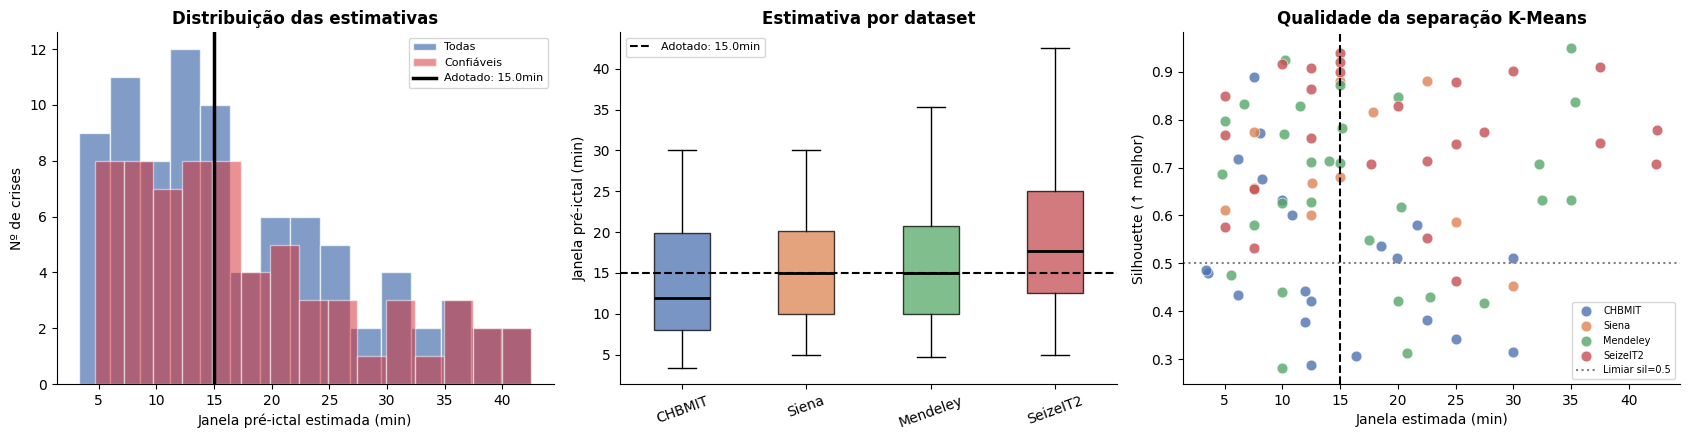

💾 data\nb15_viz\v1_estimativas.png


In [23]:
# Coleta viz_cache de todos os datasets
_VIZ_CACHE = []
for ds in DATASETS:
    vc = locals().get(f'viz_{ds.lower()}_6', [])
    _VIZ_CACHE.extend(vc)
_VIZ_CACHE = _VIZ_CACHE[:5]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# 1a) Histograma
ax = axes[0]
ax.hist(df_res['preictal_est_min'], bins=min(15, len(df_res)),
        color='#4C72B0', alpha=0.7, edgecolor='white', label='Todas')
if not df_rel.empty:
    ax.hist(df_rel['preictal_est_min'], bins=min(15, len(df_rel)),
            color='#d62728', alpha=0.5, edgecolor='white', label='Confiáveis')
ax.axvline(FINAL_VAL_MIN, color='black', lw=2.5, ls='-',
           label=f'Adotado: {FINAL_VAL_MIN:.1f}min')
ax.set_title('Distribuição das estimativas', fontweight='bold')
ax.set_xlabel('Janela pré-ictal estimada (min)'); ax.set_ylabel('Nº de crises')
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

# 1b) Boxplot por dataset
ax = axes[1]
ds_order   = [d for d in DATASETS if d in df_res['dataset'].unique()]
data_by_ds = [df_res[df_res['dataset']==d]['preictal_est_min'].values for d in ds_order]
bp = ax.boxplot(data_by_ds, labels=ds_order, patch_artist=True,
                medianprops=dict(color='black', lw=2))
for patch, d in zip(bp['boxes'], ds_order):
    patch.set_facecolor(DS_COLORS[d]); patch.set_alpha(0.75)
ax.axhline(FINAL_VAL_MIN, color='black', lw=1.5, ls='--',
           label=f'Adotado: {FINAL_VAL_MIN:.1f}min')
ax.set_title('Estimativa por dataset', fontweight='bold')
ax.set_ylabel('Janela pré-ictal (min)'); ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=20); ax.spines[['top','right']].set_visible(False)

# 1c) Silhouette vs estimativa
ax = axes[2]
valid = df_res.dropna(subset=['silhouette'])
for ds in ds_order:
    sub = valid[valid['dataset']==ds]
    ax.scatter(sub['preictal_est_min'], sub['silhouette'],
               c=DS_COLORS[ds], s=60, alpha=0.8, edgecolors='white',
               linewidths=0.5, label=ds)
ax.axhline(SIL_THRESHOLD, color='gray', ls=':', lw=1.5,
           label=f'Limiar sil={SIL_THRESHOLD}')
ax.axvline(FINAL_VAL_MIN, color='black', lw=1.5, ls='--')
ax.set_title('Qualidade da separação K-Means', fontweight='bold')
ax.set_xlabel('Janela estimada (min)'); ax.set_ylabel('Silhouette (↑ melhor)')
ax.legend(fontsize=7); ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
p = os.path.join(VIZ_DIR, 'v1_estimativas.png')
plt.savefig(p, dpi=140, bbox_inches='tight'); plt.show()
print(f'💾 {p}')


## 9. Visualização 2 — Heatmap features × tempo

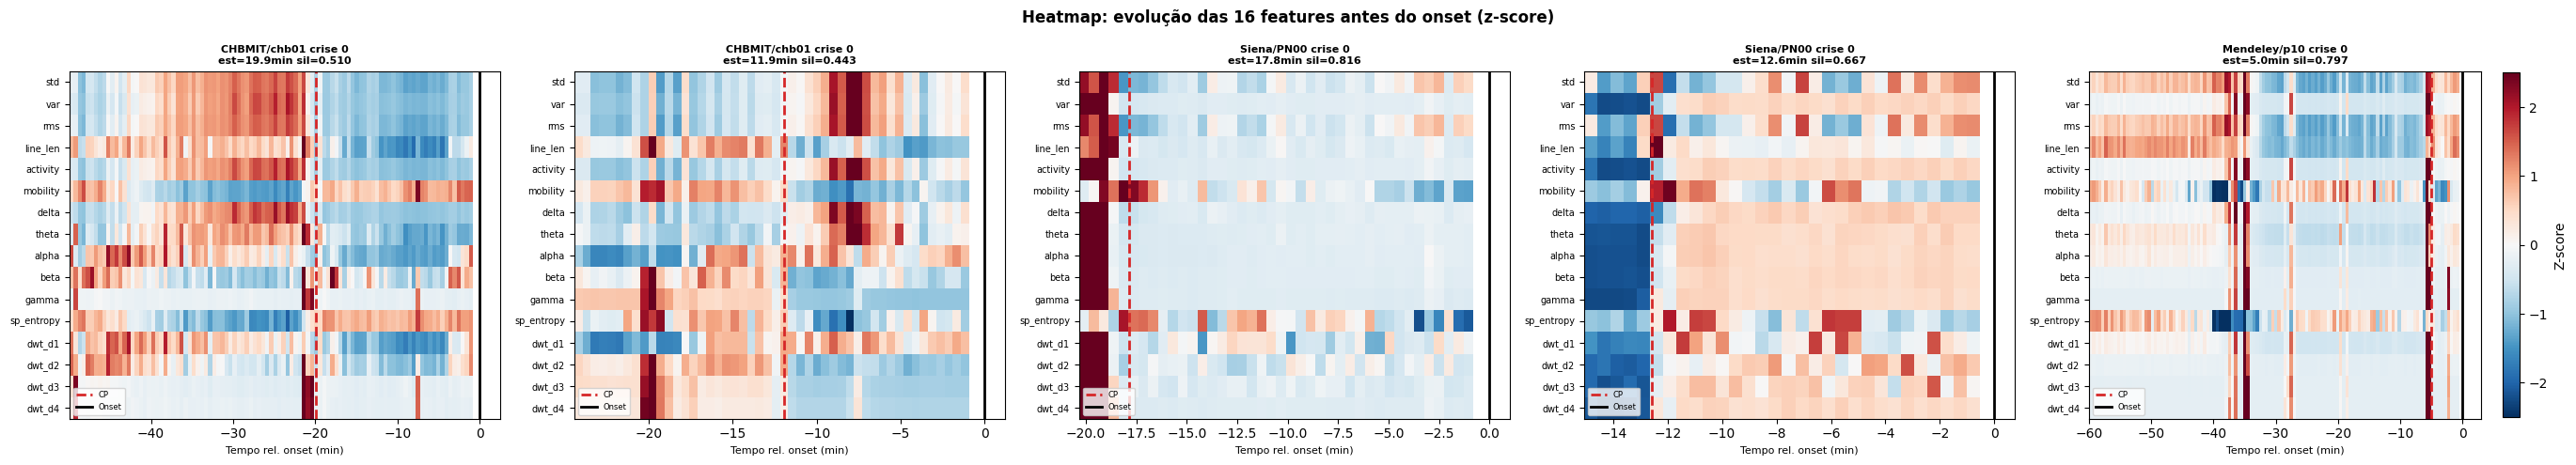

💾 data\nb15_viz\v2_heatmap.png


In [24]:
if not _VIZ_CACHE:
    print('⚠️  Cache vazio — execute as células anteriores.')
else:
    n_viz = len(_VIZ_CACHE)
    fig, axes = plt.subplots(1, n_viz, figsize=(5.5*n_viz, 5))
    if n_viz == 1: axes = [axes]
    fig.suptitle('Heatmap: evolução das 16 features antes do onset (z-score)',
                 fontsize=12, fontweight='bold')
    for ax, v in zip(axes, _VIZ_CACHE):
        sm = v['starts_min']; Xn = v['Xn']; cp = v['cp_best']
        im = ax.imshow(Xn.T, aspect='auto', cmap='RdBu_r', vmin=-2.5, vmax=2.5,
                       extent=[sm[0], sm[-1], 15.5, -0.5])
        ax.set_yticks(range(16)); ax.set_yticklabels(FEAT_NAMES, fontsize=7)
        ax.set_xlabel('Tempo rel. onset (min)', fontsize=8)
        ax.set_title(f'{v["ds"]}/{v["pat"]} crise {v["sz_idx"]}\n'
                     f'est={v["dur_min"]:.1f}min sil={v["sil"]:.3f}' if v["sil"] else
                     f'{v["ds"]}/{v["pat"]} crise {v["sz_idx"]}', fontsize=8, fontweight='bold')
        if cp is not None and cp < len(sm):
            ax.axvline(sm[cp], color='#d62728', lw=2, ls='--', label='CP')
        ax.axvline(0, color='black', lw=2, label='Onset')
        ax.legend(fontsize=6, loc='lower left')
    plt.colorbar(im, ax=axes[-1], fraction=0.04, label='Z-score')
    plt.tight_layout()
    p = os.path.join(VIZ_DIR, 'v2_heatmap.png')
    plt.savefig(p, dpi=140, bbox_inches='tight'); plt.show()
    print(f'💾 {p}')


## 10. Visualização 3 — Discriminação por feature (Cohen's d)

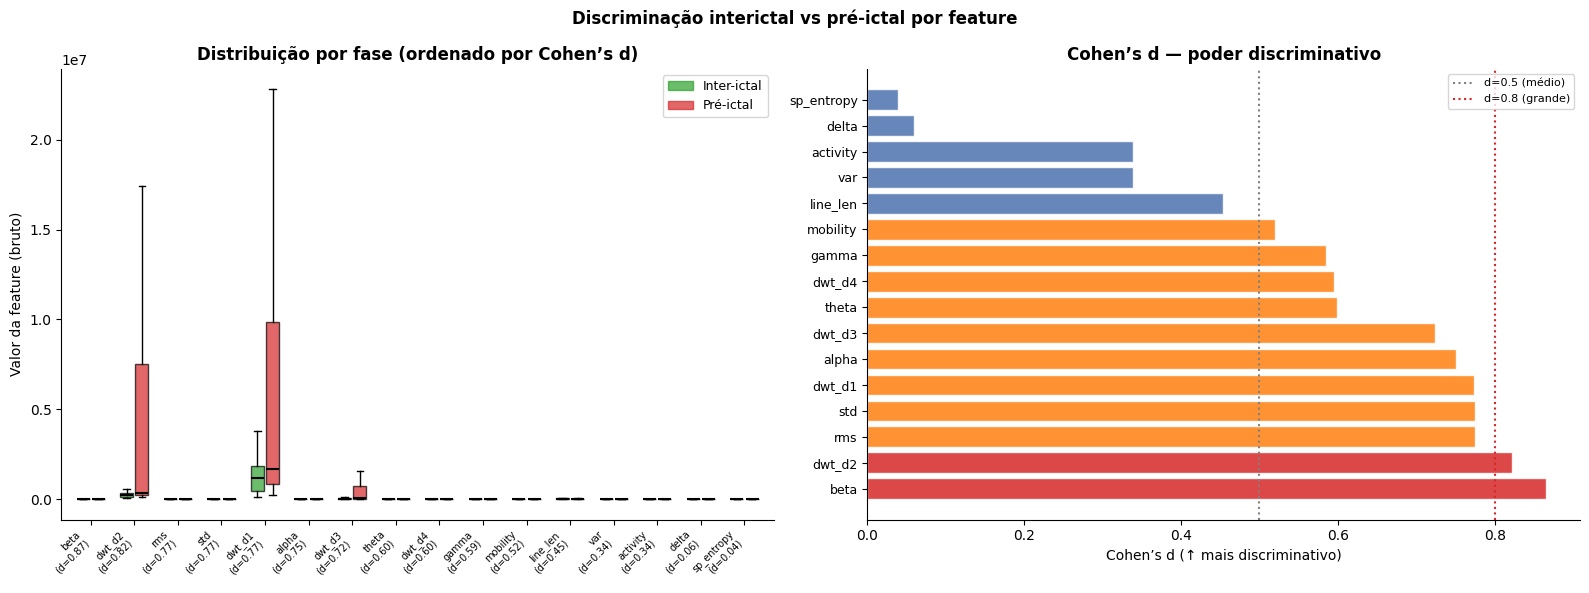

💾 data\nb15_viz\v3_cohend.png


In [25]:
if not _VIZ_CACHE:
    print('⚠️  Cache vazio.')
else:
    inter_vals = [[] for _ in range(16)]
    pre_vals   = [[] for _ in range(16)]
    for v in _VIZ_CACHE:
        cp = v['cp_best']
        if cp is None or cp <= 0: continue
        feats = v['feats']
        for fi in range(16):
            inter_vals[fi].extend(feats[:cp, fi].tolist())
            pre_vals[fi].extend(feats[cp:, fi].tolist())

    def cohen_d(a, b):
        a, b = np.array(a), np.array(b)
        if len(a) < 2 or len(b) < 2: return 0.0
        return abs(float(np.mean(b)-np.mean(a))) / np.sqrt((np.var(a)+np.var(b))/2+1e-10)

    ds_vals = sorted([(FEAT_NAMES[i], cohen_d(inter_vals[i], pre_vals[i]), i)
                      for i in range(16)], key=lambda x: x[1], reverse=True)
    feat_order = [x[2] for x in ds_vals]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Discriminação interictal vs pré-ictal por feature',
                 fontsize=12, fontweight='bold')

    ax = axes[0]
    pos = np.arange(16); w = 0.35
    for j, fi in enumerate(feat_order):
        iv, pv = inter_vals[fi], pre_vals[fi]
        if not iv or not pv: continue
        for lst, pos_off, col in [(iv, j-w/2, '#2ca02c'), (pv, j+w/2, '#d62728')]:
            bp = ax.boxplot(lst, positions=[pos_off], widths=w*0.85,
                            patch_artist=True, sym='',
                            medianprops=dict(color='black', lw=1.5))
            bp['boxes'][0].set_facecolor(col); bp['boxes'][0].set_alpha(0.7)
    ax.set_xticks(pos)
    ax.set_xticklabels([f'{x[0]}\n(d={x[1]:.2f})' for x in ds_vals],
                       rotation=45, ha='right', fontsize=7)
    ax.set_title('Distribuição por fase (ordenado por Cohen\u2019s d)', fontweight='bold')
    ax.set_ylabel('Valor da feature (bruto)')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#2ca02c', alpha=0.7, label='Inter-ictal'),
                       Patch(color='#d62728', alpha=0.7, label='Pré-ictal')], fontsize=9)
    ax.spines[['top','right']].set_visible(False)

    ax = axes[1]
    colors_d = ['#d62728' if x[1]>0.8 else '#ff7f0e' if x[1]>0.5 else '#4C72B0'
                for x in ds_vals]
    ax.barh(range(16), [x[1] for x in ds_vals], color=colors_d, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(16)); ax.set_yticklabels([x[0] for x in ds_vals], fontsize=9)
    ax.axvline(0.5, color='gray',    ls=':', lw=1.5, label='d=0.5 (médio)')
    ax.axvline(0.8, color='#d62728', ls=':', lw=1.5, label='d=0.8 (grande)')
    ax.set_title('Cohen\u2019s d — poder discriminativo', fontweight='bold')
    ax.set_xlabel('Cohen\u2019s d (↑ mais discriminativo)')
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    p = os.path.join(VIZ_DIR, 'v3_cohend.png')
    plt.savefig(p, dpi=140, bbox_inches='tight'); plt.show()
    print(f'💾 {p}')


## 11. Visualização 4 — PCA: separabilidade das classes

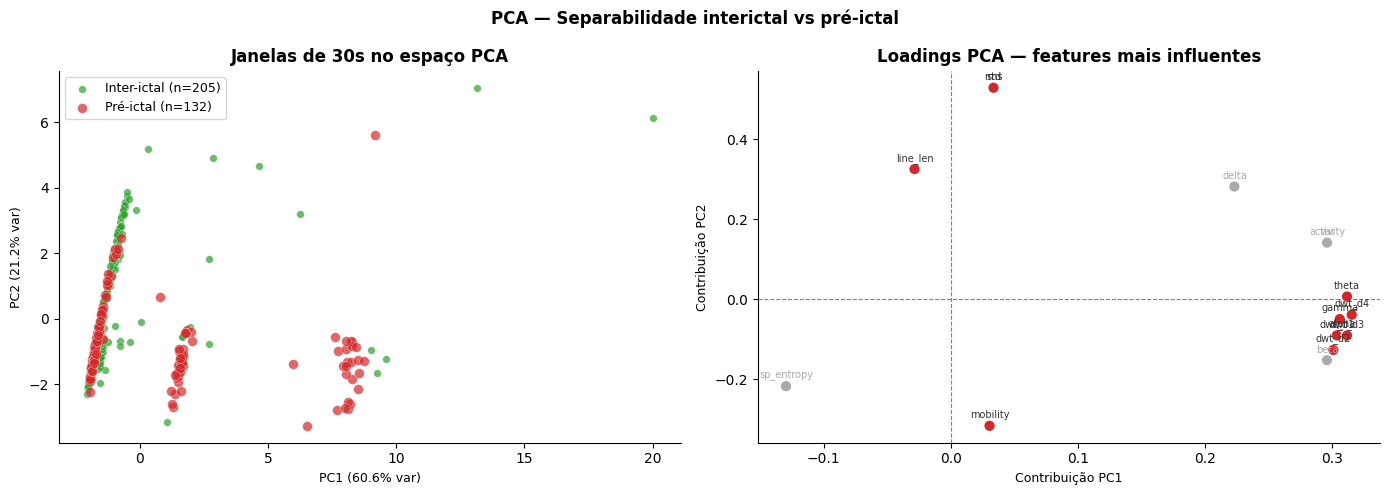

💾 data\nb15_viz\v4_pca.png


In [26]:
if not _VIZ_CACHE:
    print('⚠️  Cache vazio.')
else:
    all_feats, all_labels = [], []
    for v in _VIZ_CACHE:
        cp = v['cp_best']
        if cp is None or cp <= 0: continue
        feats = v['feats']
        all_feats.extend(feats[:cp].tolist()); all_labels.extend([0]*cp)
        all_feats.extend(feats[cp:].tolist()); all_labels.extend([1]*(len(feats)-cp))

    if len(all_feats) >= 4:
        Xall = np.array(all_feats, dtype=np.float32)
        yall = np.array(all_labels)
        Xsc  = StandardScaler().fit_transform(Xall)
        pca  = PCA(n_components=2, random_state=42)
        Xpca = pca.fit_transform(Xsc)
        var_exp = pca.explained_variance_ratio_ * 100

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('PCA — Separabilidade interictal vs pré-ictal',
                     fontsize=12, fontweight='bold')

        ax = axes[0]
        for cls, col, lbl, sz in [(0,'#2ca02c','Inter-ictal',30),(1,'#d62728','Pré-ictal',50)]:
            mask = yall == cls
            ax.scatter(Xpca[mask,0], Xpca[mask,1], c=col, s=sz, alpha=0.7,
                       edgecolors='white', linewidths=0.3, label=f'{lbl} (n={mask.sum()})')
        ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% var)', fontsize=9)
        ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% var)', fontsize=9)
        ax.set_title('Janelas de 30s no espaço PCA', fontweight='bold')
        ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

        ax = axes[1]
        loadings = pca.components_.T
        xl, yl = loadings[:,0], loadings[:,1]
        colors_l = ['#d62728' if abs(x)>0.3 or abs(y)>0.3 else '#aaaaaa'
                    for x,y in zip(xl,yl)]
        ax.scatter(xl, yl, c=colors_l, s=70, zorder=3, edgecolors='white')
        for i, name in enumerate(FEAT_NAMES):
            ax.annotate(name, (xl[i], yl[i]), fontsize=7, ha='center', va='bottom',
                        xytext=(0,4), textcoords='offset points',
                        color='#333333' if abs(xl[i])>0.3 or abs(yl[i])>0.3 else '#aaaaaa')
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.axvline(0, color='gray', lw=0.8, ls='--')
        ax.set_xlabel('Contribuição PC1', fontsize=9)
        ax.set_ylabel('Contribuição PC2', fontsize=9)
        ax.set_title('Loadings PCA — features mais influentes', fontweight='bold')
        ax.spines[['top','right']].set_visible(False)

        plt.tight_layout()
        p = os.path.join(VIZ_DIR, 'v4_pca.png')
        plt.savefig(p, dpi=140, bbox_inches='tight'); plt.show()
        print(f'💾 {p}')
    else:
        print('⚠️  Poucos dados para PCA.')


## 12. Visualização 5 — Top-3 features: série temporal por crise

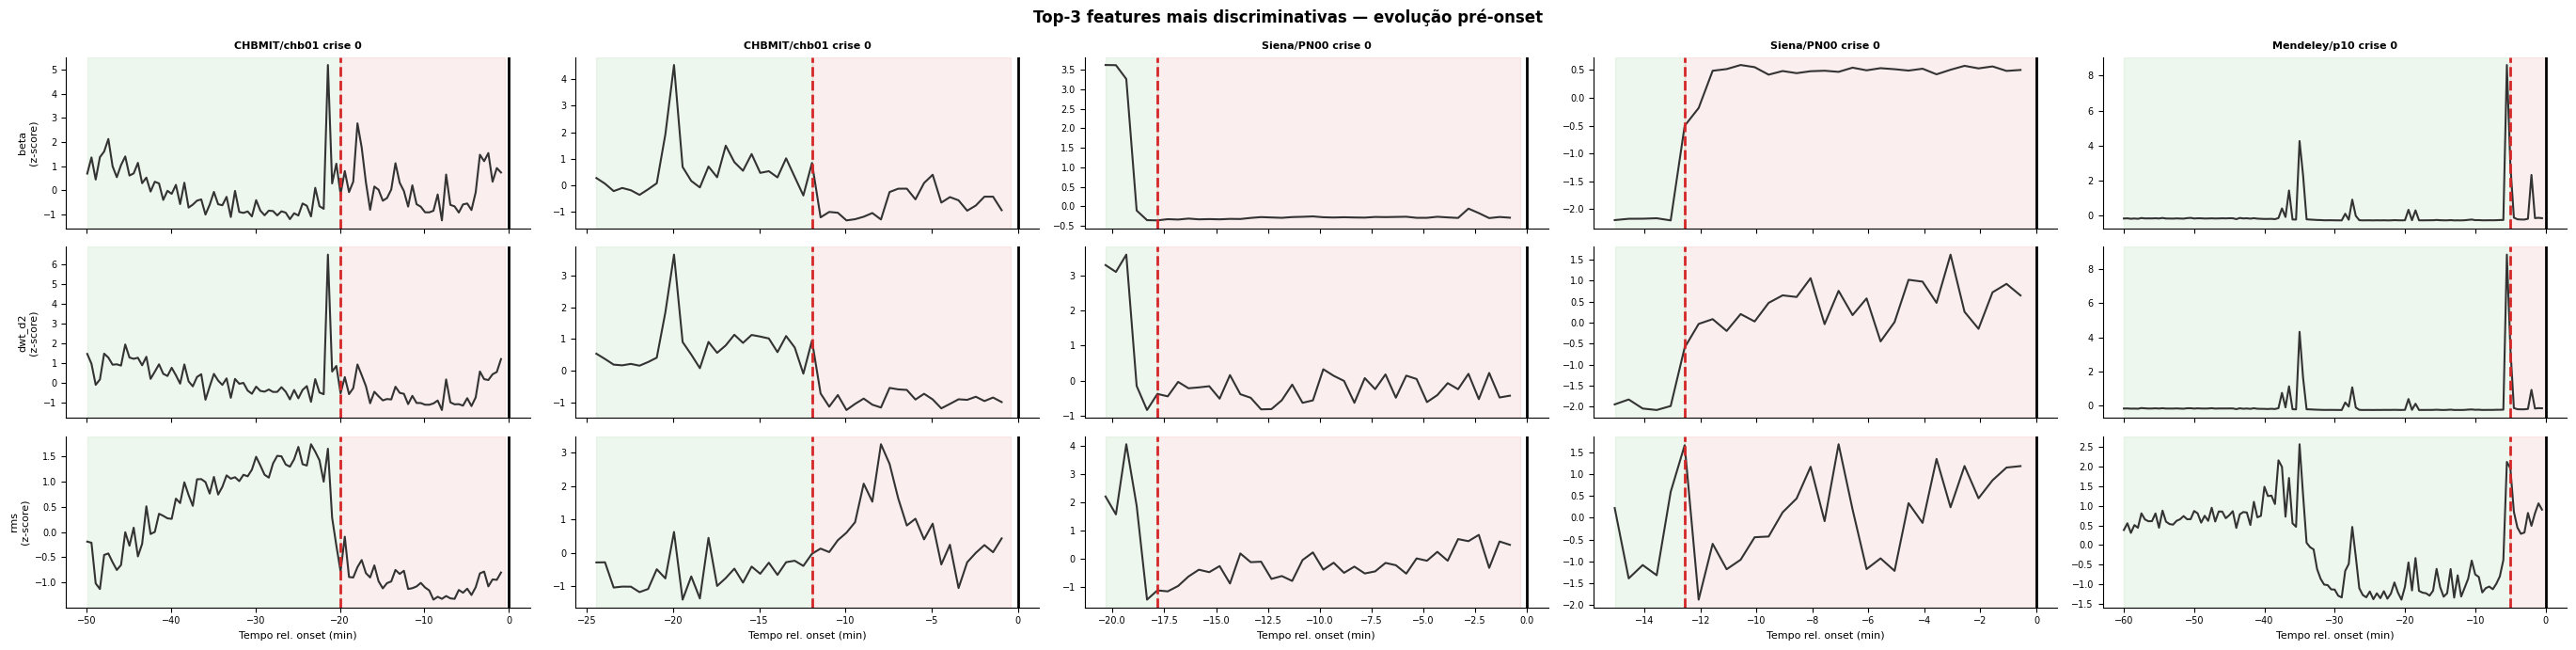

💾 data\nb15_viz\v5_top3_features.png


In [27]:
if not _VIZ_CACHE or 'ds_vals' not in dir():
    print('⚠️  Execute as células anteriores (Cohen\'s d) primeiro.')
else:
    top3_idx = [x[2] for x in ds_vals[:3]]
    top3_nms = [x[0] for x in ds_vals[:3]]
    n = len(_VIZ_CACHE)
    fig, axes = plt.subplots(3, n, figsize=(5.5*n, 7), sharex='col')
    if n == 1: axes = axes.reshape(3, 1)
    fig.suptitle('Top-3 features mais discriminativas — evolução pré-onset',
                 fontsize=12, fontweight='bold')
    for col, v in enumerate(_VIZ_CACHE):
        cp = v['cp_best']; sm = v['starts_min']; Xn = v['Xn']
        for row, (fi, fn) in enumerate(zip(top3_idx, top3_nms)):
            ax = axes[row, col]
            if cp is not None and cp < len(sm):
                ax.axvspan(sm[0], sm[min(cp,len(sm)-1)],
                           alpha=0.08, color='#2ca02c')
                ax.axvspan(sm[min(cp,len(sm)-1)], sm[-1]+0.5,
                           alpha=0.08, color='#d62728')
            ax.plot(sm, Xn[:, fi], lw=1.5, color='#333333')
            if cp is not None and cp < len(sm):
                ax.axvline(sm[cp], color='#d62728', lw=2, ls='--')
            ax.axvline(0, color='black', lw=2)
            if row == 0:
                ax.set_title(f'{v["ds"]}/{v["pat"]} crise {v["sz_idx"]}',
                             fontsize=8, fontweight='bold')
            if col == 0: ax.set_ylabel(f'{fn}\n(z-score)', fontsize=8)
            if row == 2: ax.set_xlabel('Tempo rel. onset (min)', fontsize=8)
            ax.spines[['top','right']].set_visible(False)
            ax.tick_params(labelsize=7)
    plt.tight_layout()
    p = os.path.join(VIZ_DIR, 'v5_top3_features.png')
    plt.savefig(p, dpi=140, bbox_inches='tight'); plt.show()
    print(f'💾 {p}')


---
## Resumo

| Arquivo | Conteúdo |
|---|---|
| `data/preictal_estimate.json` | JSON com `PRE_SEC_ESTIMATED` e todas as estatísticas |
| `nb15_viz/v0_convergence.png` | Convergência da estimativa 1→3→6 pacientes |
| `nb15_viz/v1_estimativas.png` | Histograma + boxplot por dataset + silhouette |
| `nb15_viz/v2_heatmap.png` | Heatmap features × tempo por crise |
| `nb15_viz/v3_cohend.png` | Cohen's d — ranking de discriminação das features |
| `nb15_viz/v4_pca.png` | PCA scatter + loadings |
| `nb15_viz/v5_top3_features.png` | Top-3 features no tempo com changepoint |

**Próximos passos:**
1. Apague `data/level1_signals/`
2. Re-execute o **NB1** — lê `preictal_estimate.json` automaticamente
3. Execute o **NB2**
